In [38]:
import tensorflow as tf
import numpy as np
tf.random.set_seed(1)

In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Activation

In [40]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

gray_scale = 255
x_train /= gray_scale
x_test /= gray_scale

In [41]:
model = Sequential([
    Flatten(input_shape=(28, 28)),    # reshape 28 row * 28 column data to 28*28=784 rows
    Dense(256, activation='sigmoid'), # dense layer 1
    Dense(128, activation='sigmoid'), # dense layer 2
    Dense(10, activation='softmax'),  # dense layer 3
])

In [42]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.layers
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.fit(x_train, y_train, epochs=10, batch_size=2000, validation_split = 0.2)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.4289 - loss: 2.0308 - val_accuracy: 0.7202 - val_loss: 1.6328
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7423 - loss: 1.2895 - val_accuracy: 0.8229 - val_loss: 0.9411
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8321 - loss: 0.7917 - val_accuracy: 0.8714 - val_loss: 0.6131
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8730 - loss: 0.5568 - val_accuracy: 0.8935 - val_loss: 0.4579
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8918 - loss: 0.4396 - val_accuracy: 0.9047 - val_loss: 0.3796
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9025 - loss: 0.3760 - val_accuracy: 0.9121 - val_loss: 0.3348
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9099 - loss: 0.3365 - val_accuracy: 0.9177 - val_loss: 0.3054
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9160 - loss: 0.3090 - val_accuracy: 0.9224 - v

In [44]:
results = model.evaluate(x_test, y_test, verbose = 2)

313/313 - 1s - 3ms/step - accuracy: 0.9256 - loss: 0.2589


In [45]:
print(results)

[0.2588981091976166, 0.925599992275238]


In [46]:
from matplotlib import pyplot as plt

In [47]:
i=2013
image = x_test[i]*255
print(image.shape)

(28, 28)


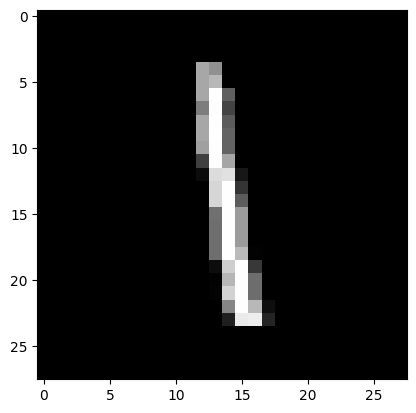

In [48]:
image = np.array(image, dtype='uint8')
plt.imshow(image, cmap='gray')

In [49]:
y_test[i]

np.uint8(1)

In [50]:
pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [51]:
print(pred[i])

[0.00 0.98 0.00 0.00 0.00 0.01 0.00 0.00 0.01 0.00]


In [52]:
np.set_printoptions(edgeitems=10, linewidth=130, formatter=dict(float=lambda x: "%4.2f" % x))
print(pred)

[[0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.99 0.00 0.00]
 [0.01 0.00 0.96 0.01 0.00 0.01 0.01 0.00 0.00 0.00]
 [0.00 0.98 0.01 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.99 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.95 0.00 0.00 0.01 0.00 0.03]
 [0.00 0.98 0.00 0.00 0.00 0.00 0.00 0.01 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.94 0.02 0.00 0.00 0.02 0.02]
 [0.00 0.00 0.00 0.00 0.05 0.01 0.00 0.00 0.01 0.92]
 [0.01 0.00 0.01 0.00 0.16 0.03 0.78 0.00 0.01 0.00]
 [0.00 0.00 0.00 0.00 0.02 0.00 0.00 0.03 0.00 0.95]
 ...
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.98 0.00 0.01]
 [0.00 0.00 0.01 0.06 0.00 0.01 0.00 0.00 0.91 0.00]
 [0.00 0.00 0.00 0.00 0.24 0.00 0.00 0.01 0.00 0.74]
 [0.97 0.00 0.00 0.00 0.00 0.02 0.00 0.00 0.00 0.00]
 [0.00 0.98 0.01 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.98 0.01 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.99 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.92 0.01 0.00 0.00 0.01 0.06]
 [0.00 0.00 0.00 0.00 0.00 0.90 0.00 0.00

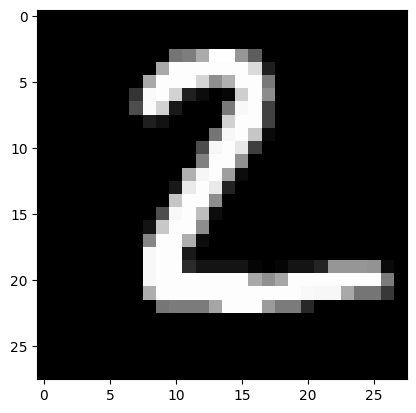

In [53]:
image = np.array(x_test[1]*255, dtype='uint8')
plt.imshow(image, cmap='gray')